# Superconductivity Gap


In [1]:
# pylint: disable = C0103, C0114, C0116, C0301, R0914, R0915, W0612

# Necessary packages invoking
import os
import glob
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from scipy.optimize import curve_fit

mpl.rcParams["lines.solid_capstyle"] = "round"
mpl.rcParams["lines.dash_capstyle"]  = "round"
mpl.rcParams["lines.solid_joinstyle"] = "round"
mpl.rcParams["lines.dash_joinstyle"]  = "round"

def process_boundary(boundary, default=(None, None)):
    # Enhanced to handle single values as well as tuples/lists
    # If boundary is None or empty, return the default
    if not boundary:
        return default
    # If boundary is a single value (not a container), treat it as the end value
    if isinstance(boundary, (int, float)):
        return (None, boundary)
    # If boundary is a container with a single item, unpack it
    if isinstance(boundary, (list, tuple)) and len(boundary) == 1:
        return (None, boundary[0])
    # If boundary is a container with two items, return them as start and end
    elif isinstance(boundary, (list, tuple)) and len(boundary) == 2:
        return (boundary[0], boundary[1])
    # In case boundary doesn't match any expected pattern, return default
    else:
        return default

def load_gap_data_files(target_directory=".", file_patterns=None):
    """
    Load superconducting gap data files from the target directory.
    The first column is temperature and the second column is superconducting gap.
    """
    if file_patterns is None:
        file_patterns = ["B14.imag_aniso_gap0_*.dat", "B14.imag_aniso_gap0_*"]

    all_files = []
    for pattern in file_patterns:
        all_files.extend(glob.glob(os.path.join(target_directory, pattern)))

    all_files = sorted(set(all_files))
    if len(all_files) == 0:
        raise FileNotFoundError(f"No superconducting-gap data files were found in {target_directory}.")

    temperature = []
    superconducting_gap = []

    for filename in all_files:
        if os.path.exists(filename):
            try:
                data = np.loadtxt(filename)
                if data.ndim == 1:
                    data = data.reshape(1, -1)

                temperature.extend(data[:, 0])
                superconducting_gap.extend(data[:, 1])

            except Exception as e:
                print(f"Warning: Could not load {filename}: {e}")

    temperature = np.array(temperature, dtype=float)
    superconducting_gap = np.array(superconducting_gap, dtype=float)

    finite_mask = np.isfinite(temperature) & np.isfinite(superconducting_gap)
    temperature = temperature[finite_mask]
    superconducting_gap = superconducting_gap[finite_mask]

    sort_index = np.argsort(temperature)
    temperature = temperature[sort_index]
    superconducting_gap = superconducting_gap[sort_index]

    return temperature, superconducting_gap


def power_law_gap_function(T, Delta_0, T_c, n):
    """
    Power-law superconducting gap function:
    Delta(T) = Delta_0 * sqrt(1 - (T/T_c)^n).
    """
    T = np.asarray(T, dtype=float)
    ratio = T / T_c
    condition = ratio < 1
    result = np.zeros_like(T, dtype=float)

    valid_ratios = ratio[condition]
    if len(valid_ratios) > 0:
        base = np.maximum(0, 1 - np.power(valid_ratios, n))
        result[condition] = Delta_0 * np.sqrt(base)

    return result


def phenomenological_gap_function(T, Delta_0, T_c, alpha):
    """
    Phenomenological superconducting gap function:
    Delta(T) = Delta_0 * tanh(alpha * sqrt((T_c - T)/T_c)).
    """
    T = np.asarray(T, dtype=float)
    condition = T < T_c
    result = np.zeros_like(T, dtype=float)

    valid_T = T[condition]
    if len(valid_T) > 0:
        arg = alpha * np.sqrt(np.maximum(0, (T_c - valid_T) / T_c))
        result[condition] = Delta_0 * np.tanh(arg)

    return result

def fit_superconducting_gap(temperature, superconducting_gap, fitting="power", fit_boundary=None):
    """
    Fit superconducting gap data with a selected gap function.
    fitting: "power", "phenomenological", or "auto".
    """
    temperature = np.asarray(temperature, dtype=float)
    superconducting_gap = np.asarray(superconducting_gap, dtype=float)

    fit_mask = np.isfinite(temperature) & np.isfinite(superconducting_gap)
    fit_mask &= superconducting_gap > 0

    if fit_boundary is not None:
        fit_low, fit_high = process_boundary(fit_boundary)

        if fit_low is not None:
            fit_mask &= temperature >= fit_low
        if fit_high is not None:
            fit_mask &= temperature <= fit_high

    T_fit = temperature[fit_mask]
    Delta_fit = superconducting_gap[fit_mask]

    if len(T_fit) < 8:
        raise RuntimeError("Not enough valid data points for fitting.")

    sort_index = np.argsort(T_fit)
    T_fit = T_fit[sort_index]
    Delta_fit = Delta_fit[sort_index]

    Delta_0_guess = np.percentile(Delta_fit, 95)
    threshold = 0.1 * Delta_0_guess
    T_candidates = T_fit[Delta_fit > threshold]
    T_c_guess = np.max(T_candidates) * 1.1 if len(T_candidates) > 0 else np.max(T_fit) * 1.1

    Delta_upper = max(Delta_0_guess * 3, np.max(Delta_fit) * 2, 1)
    T_c_upper = max(np.max(T_fit) * 2, 50)

    fit_models = []

    if fitting in ["power", "auto"]:
        fit_models.append(["power", power_law_gap_function,
                           [Delta_0_guess, T_c_guess, 2.0],
                           [0.01, 1, 0.2],
                           [Delta_upper, T_c_upper, 8.0]])

    if fitting in ["phenomenological", "auto"]:
        fit_models.append(["phenomenological", phenomenological_gap_function,
                           [Delta_0_guess, T_c_guess, 1.76],
                           [0.01, 1, 0.2],
                           [Delta_upper, T_c_upper, 8.0]])

    last_error = None
    for fit_name, fit_function, initial_guess, lower_bound, upper_bound in fit_models:
        try:
            popt, pcov = curve_fit(fit_function, T_fit, Delta_fit,
                                   p0=initial_guess, bounds=(lower_bound, upper_bound),
                                   maxfev=10000, method="trf")

            Delta_predicted = fit_function(T_fit, *popt)
            ss_res = np.sum((Delta_fit - Delta_predicted) ** 2)
            ss_tot = np.sum((Delta_fit - np.mean(Delta_fit)) ** 2)
            r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            param_errors = np.sqrt(np.diag(pcov)) if pcov is not None else np.zeros_like(popt)

            return {"name": fit_name,
                    "function": fit_function,
                    "parameters": popt,
                    "errors": param_errors,
                    "r_squared": r_squared,
                    "temperature": T_fit,
                    "gap": Delta_fit}

        except Exception as e:
            last_error = e

    raise RuntimeError(f"All fitting methods failed: {last_error}")

def _apply_axis_boundary(axis_name, boundary):
    """
    Apply x or y axis boundary while allowing None as one side.
    """
    if boundary is None:
        return

    boundary_low, boundary_high = process_boundary(boundary)

    if axis_name == "x":
        current_low, current_high = plt.xlim()
        if boundary_low is None:
            boundary_low = current_low
        if boundary_high is None:
            boundary_high = current_high
        plt.xlim(boundary_low, boundary_high)

    elif axis_name == "y":
        current_low, current_high = plt.ylim()
        if boundary_low is None:
            boundary_low = current_low
        if boundary_high is None:
            boundary_high = current_high
        plt.ylim(boundary_low, boundary_high)

def plot_superconducting_gap(title=None, target_directory=".", fitting="power", fit_boundary=None,
                             x_boundary=None, y_boundary=(0, None), legend_loc="upper right",
                             show_fit=True, show_tc=True, grid=False, label="gap", save_name=None):
    """
    Plot superconducting gap data with vmatplot-style aesthetics.

    Args:
        title: Figure title.
        target_directory: Directory containing superconducting gap data files.
        fitting: "power", "phenomenological", or "auto".
        fit_boundary: Temperature boundary used for fitting.
        x_boundary: X-axis boundary.
        y_boundary: Y-axis boundary.
        legend_loc: Legend location.
        show_fit: Whether to plot the fitting curve.
        show_tc: Whether to mark T_c with a vertical dashed line.
        grid: Whether to show grid.
        label: Label for calculated superconducting-gap data.
        save_name: Output file name. Set to None or False to disable saving.
    """
    # Data loading
    temperature, superconducting_gap = load_gap_data_files(target_directory)

    # Figure settings
    params = {
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Liberation Serif", "Times New Roman", "Times"],
        "mathtext.fontset": "cm",
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "figure.facecolor": "w",
    }
    plt.rcParams.update(params)

    fig = plt.figure(figsize=(10, 6), dpi=196)
    ax = plt.gca()

    plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

    # Colors calling
    data_color = "#146EB4"
    fit_color = "#FAA03C"
    annotate_color = "#969696"

    # Data plotting
    plt.scatter(temperature, superconducting_gap, s=14, color=data_color, alpha=0.75, edgecolors="white", linewidths=0.40, label=label, zorder=4)

    fit_result = None
    if show_fit is True:
        fit_result = fit_superconducting_gap(temperature, superconducting_gap,
                                             fitting=fitting, fit_boundary=fit_boundary)

        fit_function = fit_result["function"]
        fit_parameters = fit_result["parameters"]
        T_c = fit_parameters[1]

        T_smooth = np.linspace(0, T_c, 500)
        Delta_smooth = fit_function(T_smooth, *fit_parameters)

        plt.plot(T_smooth, Delta_smooth, color=fit_color, linestyle="solid", lw=2, alpha=1.0,
                 label=rf"Fit, $T_\mathrm{{c}}$ = {T_c:.1f} K", zorder=0)

        if show_tc is True:
            plt.axvline(x=T_c, color=annotate_color, linestyle="--", alpha=0.75, zorder=-1)

        print(f"Fitting model: {fit_result['name']}")
        print(f"Delta_0 = {fit_parameters[0]:.3f} ± {fit_result['errors'][0]:.3f} meV")
        print(f"T_c     = {fit_parameters[1]:.3f} ± {fit_result['errors'][1]:.3f} K")
        print(f"param 3 = {fit_parameters[2]:.3f} ± {fit_result['errors'][2]:.3f}")
        print(f"R^2     = {fit_result['r_squared']:.5f}")

    # Figure title and labels
    if title not in [None, False, ""]:
        plt.title(f"{title}")

    plt.xlabel("Temperature (K)")
    plt.ylabel(r"Superconducting gap $\Delta$ (meV)")

    # Axis range
    _apply_axis_boundary("x", x_boundary)
    _apply_axis_boundary("y", y_boundary)

    # Ticks
    plt.gca().xaxis.set_major_locator(MultipleLocator(5))
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
    plt.gca().yaxis.set_major_locator(MultipleLocator(1))
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))

    # Grid
    if grid is True:
        plt.grid(color=annotate_color, linestyle="--", alpha=0.35, zorder=0)

    # Legend
    if legend_loc not in [None, False]:
        legend = plt.legend(loc=legend_loc, frameon=True, fancybox=True, shadow=False,
                            facecolor="white", edgecolor=annotate_color, framealpha=0.9)
        legend.get_frame().set_linewidth(1.0)

    plt.tight_layout()

    # Save figure
    if save_name not in [None, False, ""]:
        plt.savefig(save_name, dpi=196, bbox_inches="tight",
                    facecolor="white", edgecolor="none")


Fitting model: power
Delta_0 = 4.766 ± 0.020 meV
T_c     = 31.282 ± 0.117 K
param 3 = 2.961 ± 0.093
R^2     = 0.42866
Fitting model: power
Delta_0 = 4.766 ± 0.020 meV
T_c     = 31.282 ± 0.117 K
param 3 = 2.961 ± 0.093
R^2     = 0.42866


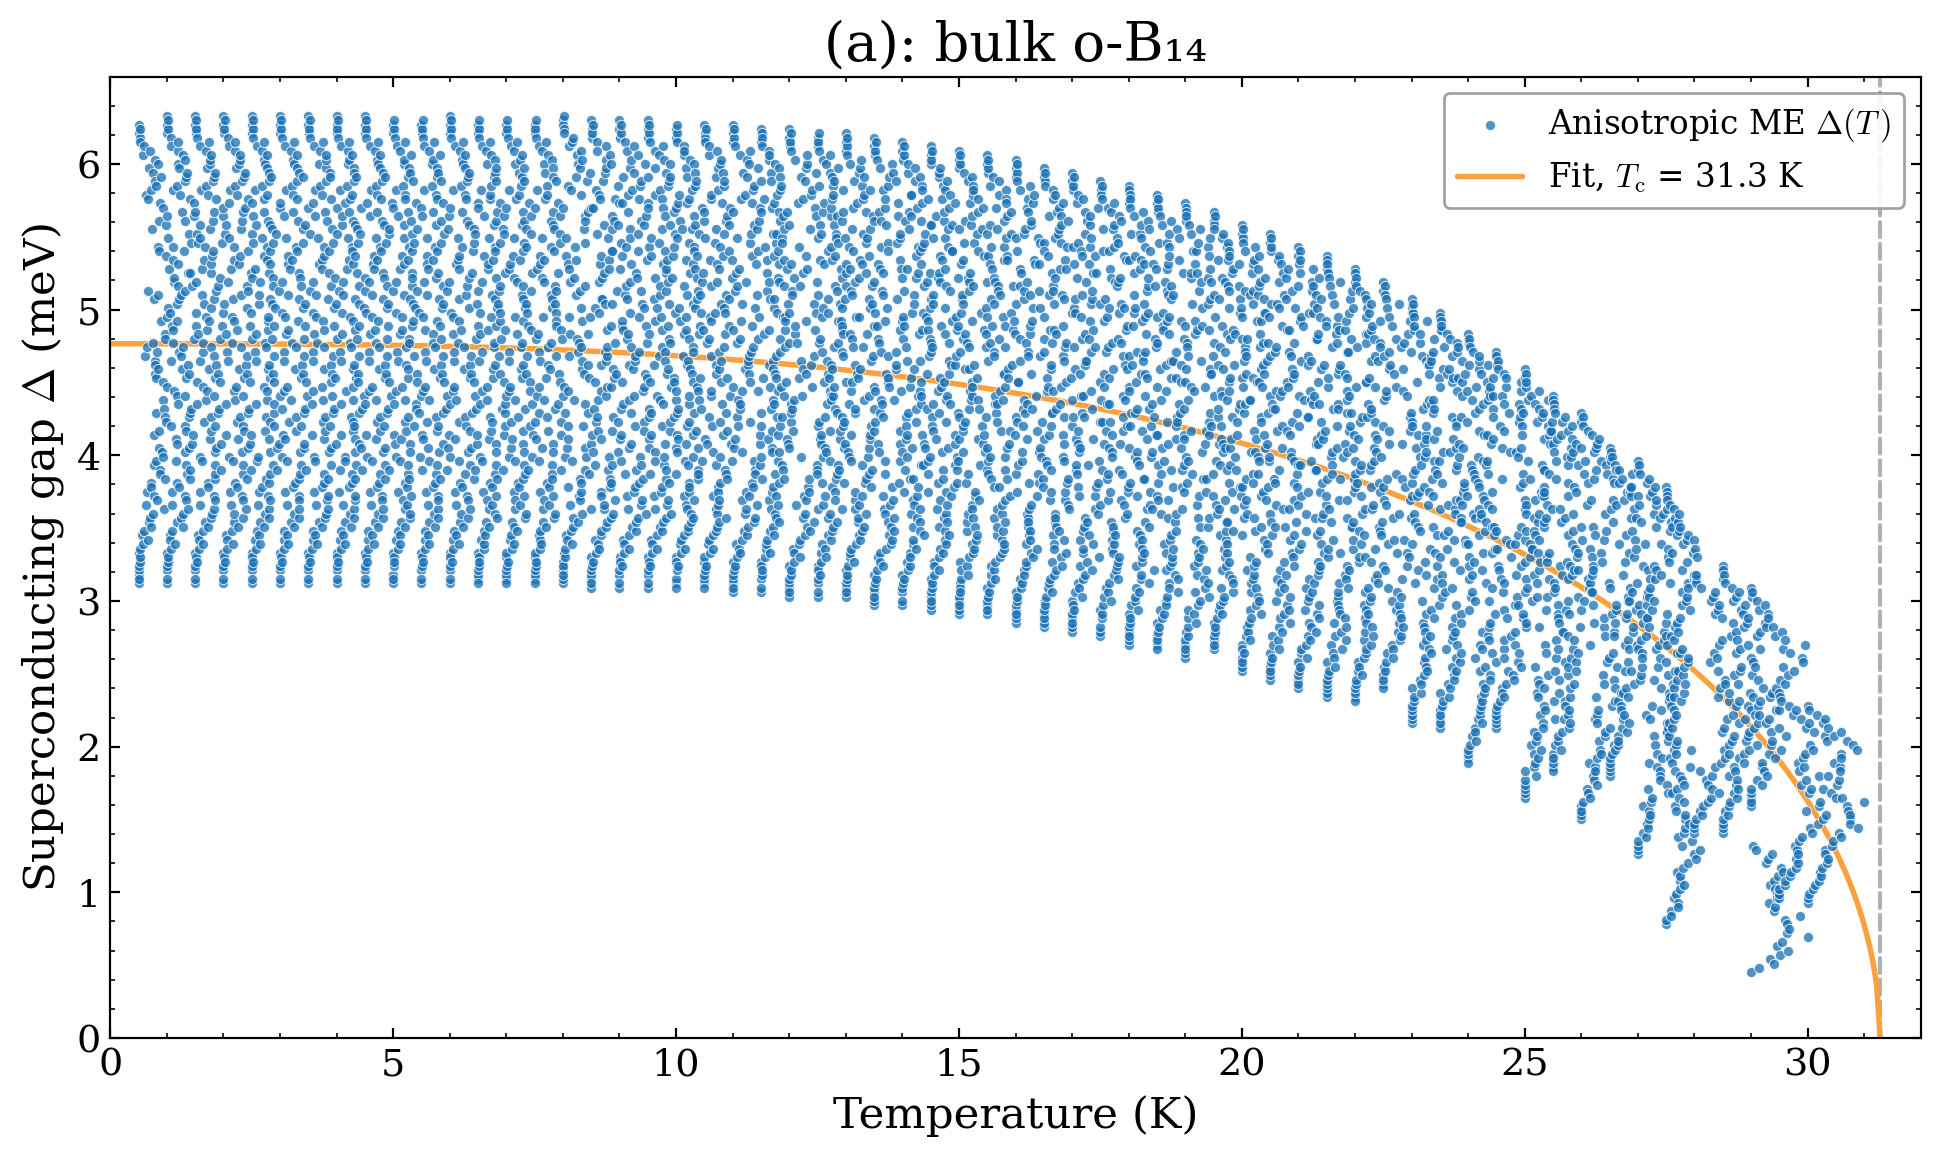

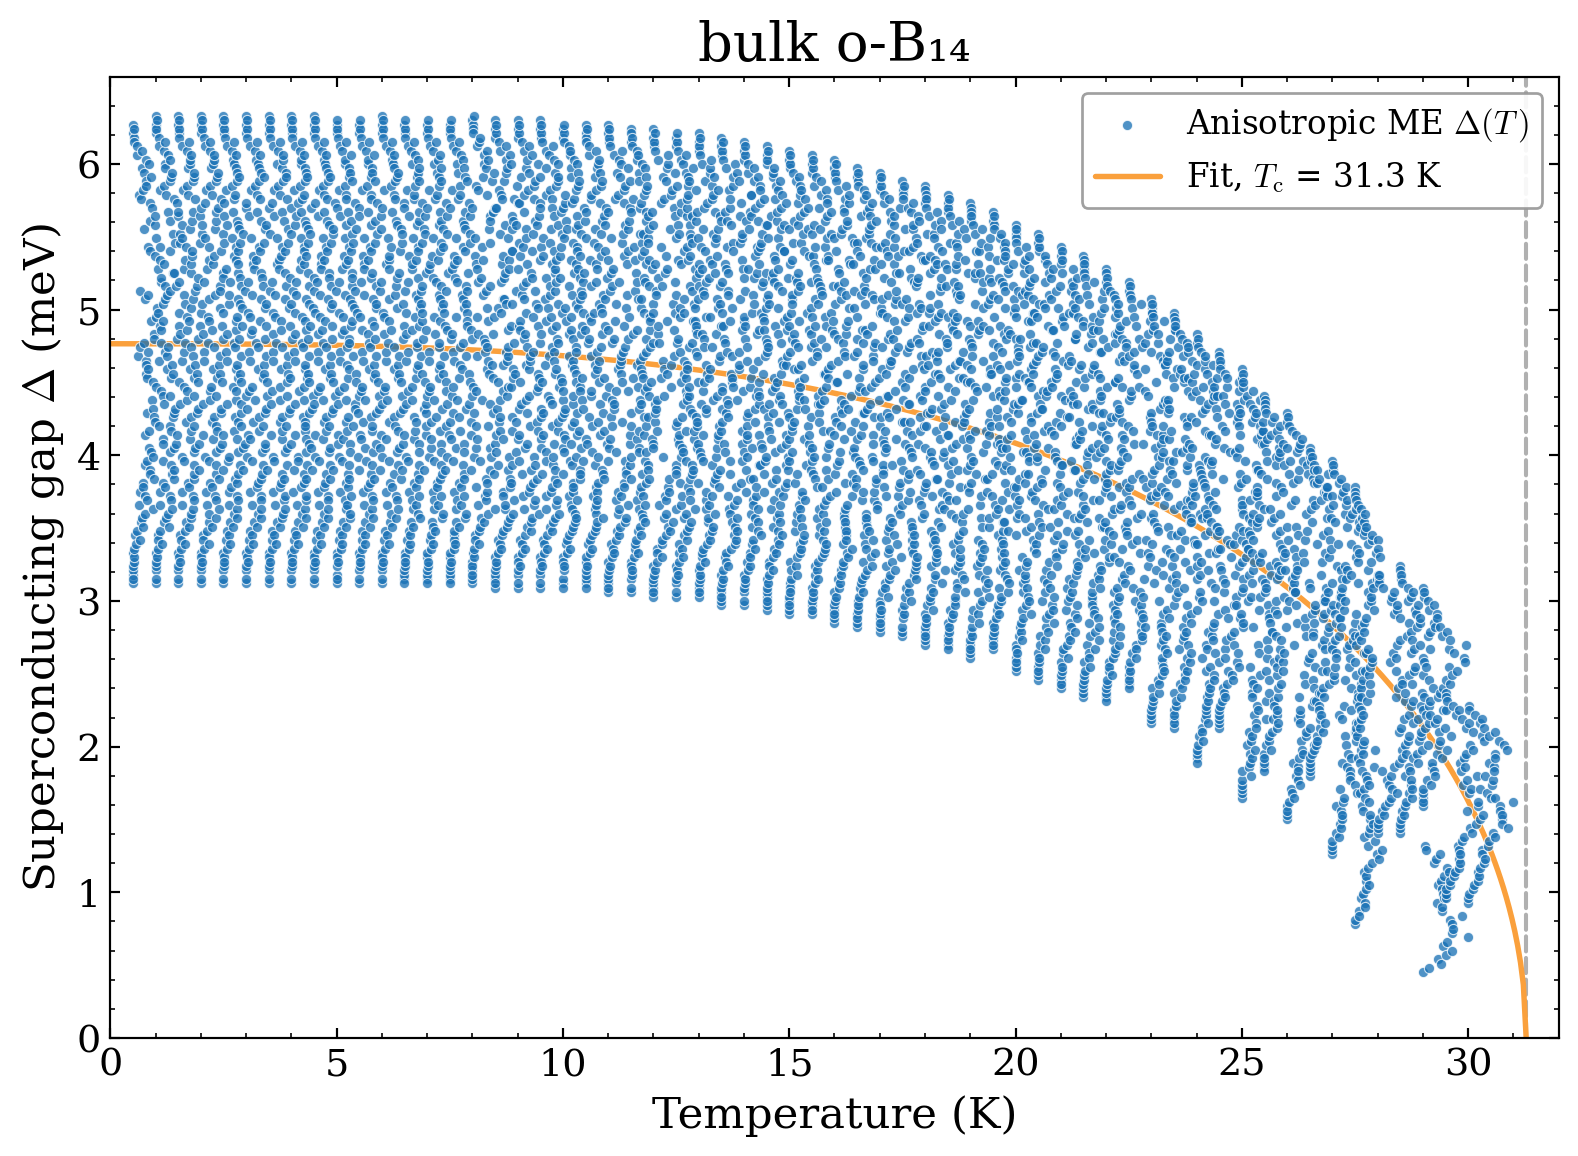

In [2]:
plot_superconducting_gap("(a): bulk o-B₁₄", "superconductivity/bulk", x_boundary = (0, 32), y_boundary=(0, 6.6), label=r"Anisotropic ME $\Delta(T\,)$",)
plt.savefig("figures/7.1_superconductivity_bulk.pdf")

plot_superconducting_gap("bulk o-B₁₄", "superconductivity/bulk", x_boundary = (0, 32), y_boundary=(0, 6.6), label=r"Anisotropic ME $\Delta(T\,)$",)

plt.savefig("figures_collection/fig2.9a_large.pdf")
fig = plt.gcf()
fig.set_size_inches(8, 6)
plt.savefig("figures_collection/fig2.9a.pdf")


Fitting model: power
Delta_0 = 3.492 ± 0.024 meV
T_c     = 24.255 ± 0.083 K
param 3 = 2.845 ± 0.126
R^2     = 0.28282
Fitting model: power
Delta_0 = 3.492 ± 0.024 meV
T_c     = 24.255 ± 0.083 K
param 3 = 2.845 ± 0.126
R^2     = 0.28282


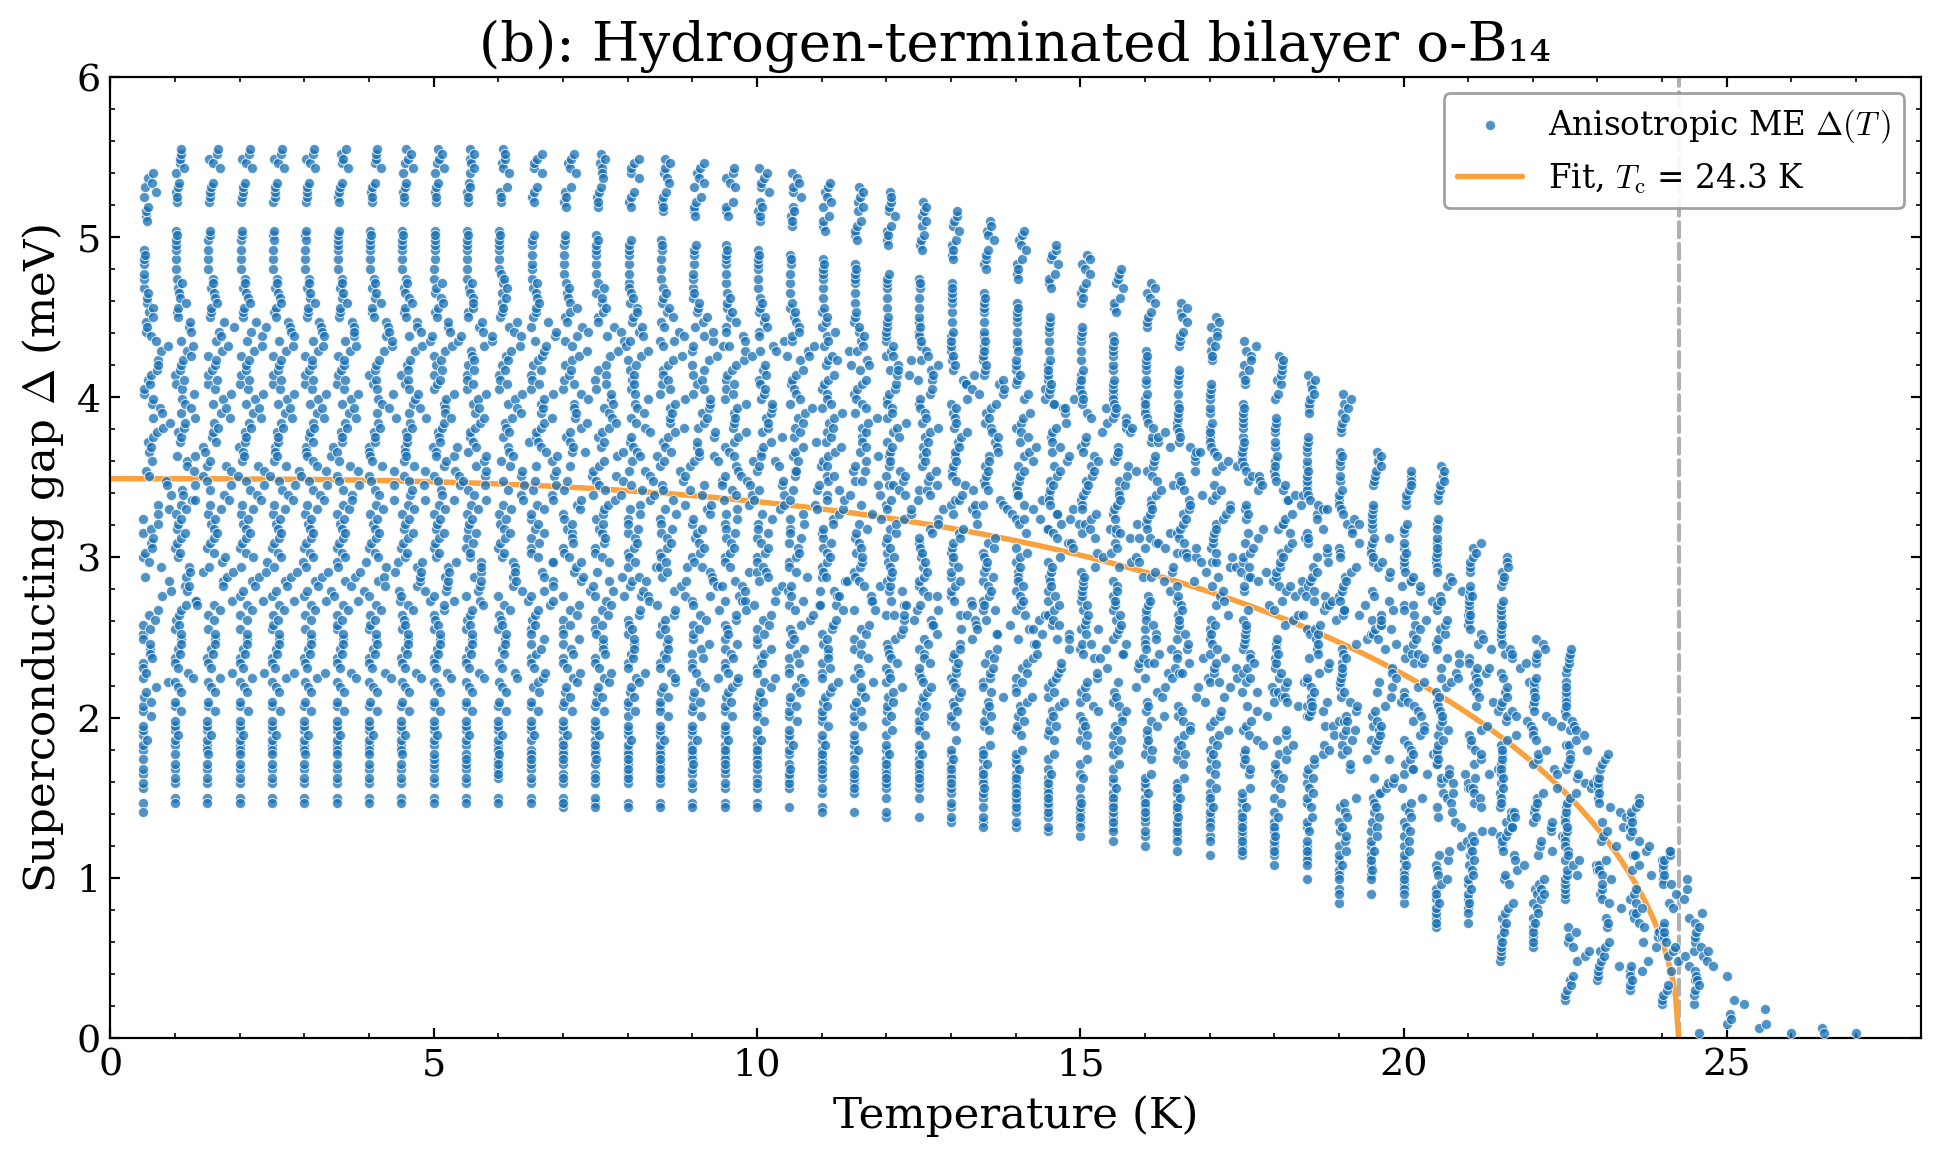

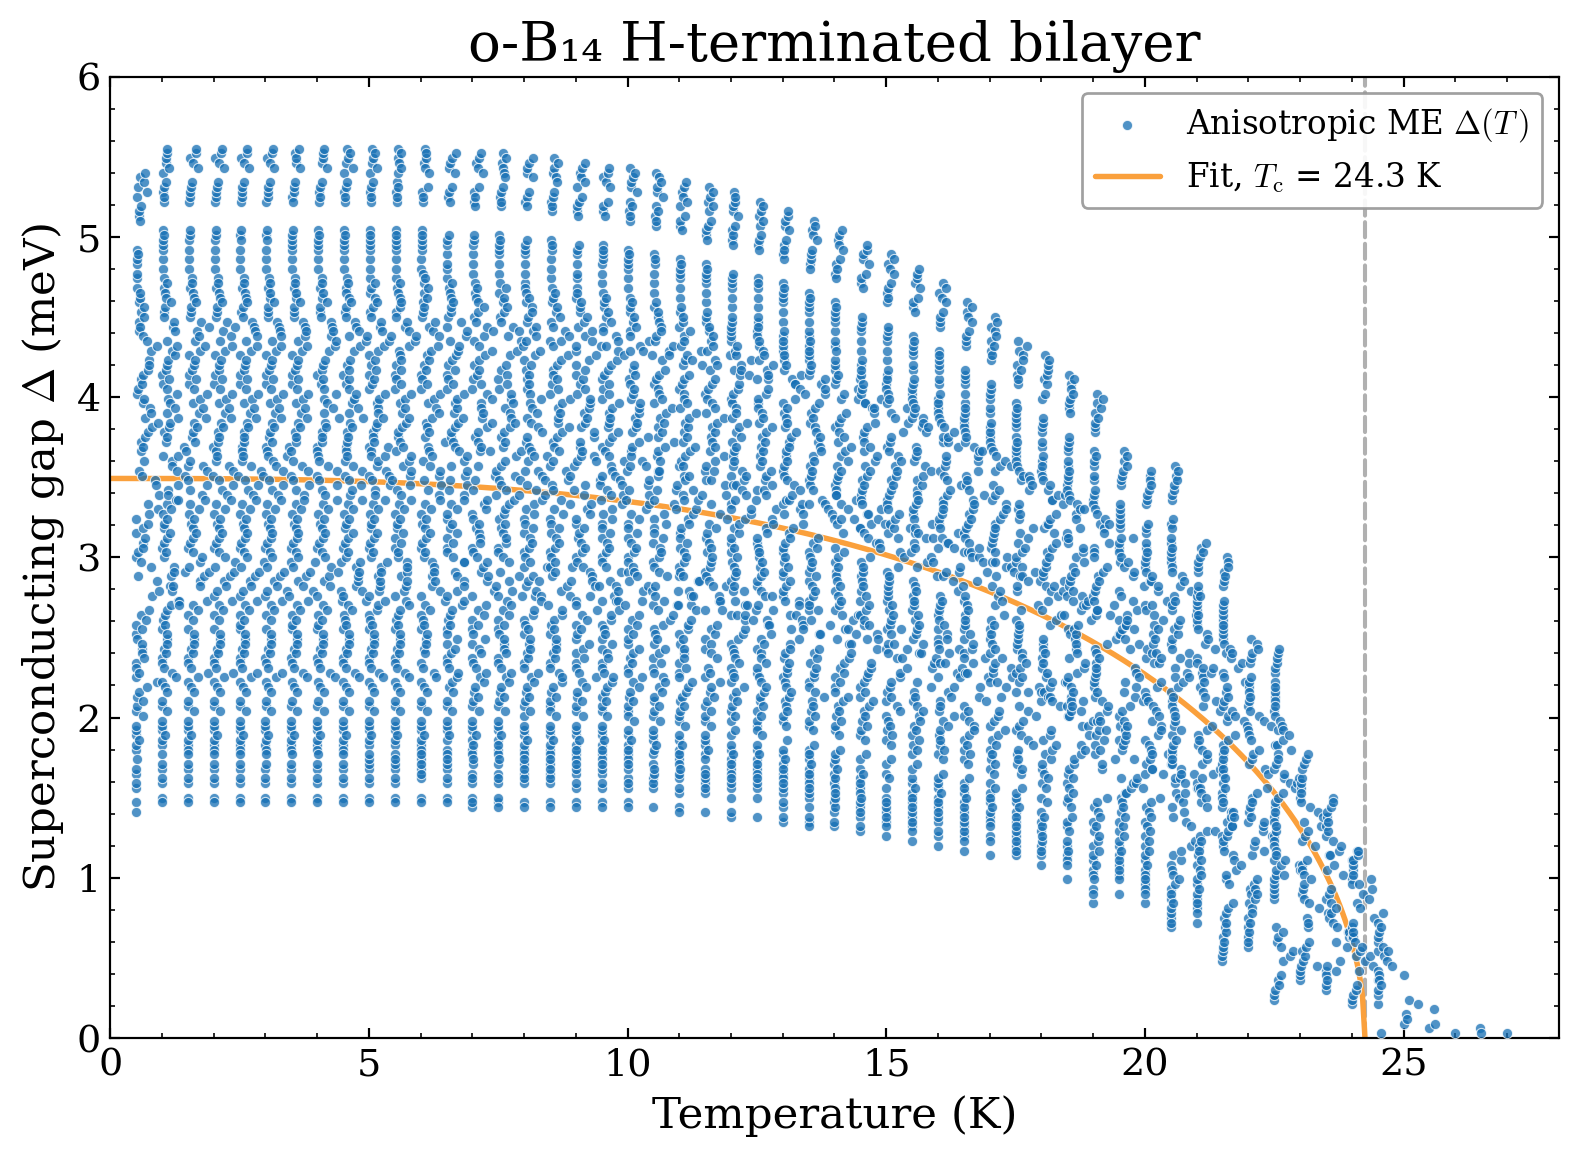

In [3]:
plot_superconducting_gap("(b): Hydrogen-terminated bilayer o-B₁₄", "superconductivity/bilayer_with_Hydrogen", x_boundary = (0, 28), y_boundary=(0, 6), label=r"Anisotropic ME $\Delta(T\,)$",)
plt.savefig("figures/7.1_superconductivity_bilayer_H.pdf")

plot_superconducting_gap("o-B₁₄ H-terminated bilayer", "superconductivity/bilayer_with_Hydrogen", x_boundary = (0, 28), y_boundary=(0, 6), label=r"Anisotropic ME $\Delta(T\,)$",)

plt.savefig("figures_collection/fig2.9b_large.pdf")
fig = plt.gcf()
fig.set_size_inches(8, 6)
plt.savefig("figures_collection/fig2.9b.pdf")
